# Flapping Wing UAV - Flight Data Analysis
This notebook analyzes the physical telemetry generated by the `SimulationLogger`.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Set up plotting directory
os.makedirs('../plot', exist_ok=True)

# Load Simulation Data
csv_path = '../plot/simulation_data.csv'
df = pd.read_csv(csv_path)
print(f"Loaded {len(df)} time steps of flight data.")

Loaded 2000 time steps of flight data.


### 1. Actuation vs Aerodynamic Lift & Thrust
Correlating the instantaneous flapping angle with the resulting Z-axis lift and X-axis thrust.

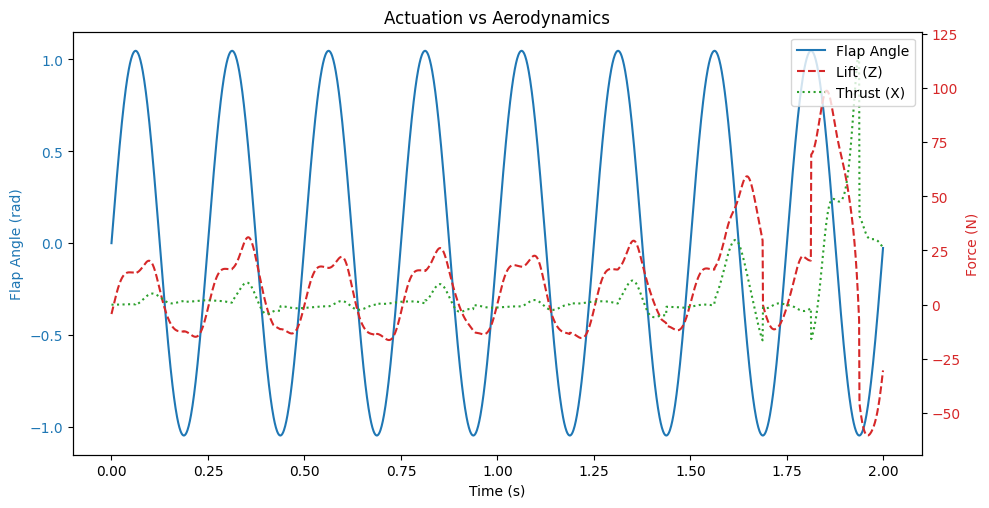

In [30]:
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Flap Angle (rad)', color=color)
ax1.plot(df['time'], df['flap_angle'], color=color, label='Flap Angle')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Force (N)', color=color)
ax2.plot(df['time'], df['force_z'], color='tab:red', linestyle='--', label='Lift (Z)')
ax2.plot(df['time'], df['force_x'], color='tab:green', linestyle=':', label='Thrust (X)')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title("Actuation vs Aerodynamics")
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.savefig('../plot/actuation_forces.png')
plt.show()

### 2. 3D Flight Trajectory
Visualizing the spatial path of the drone's center of mass.

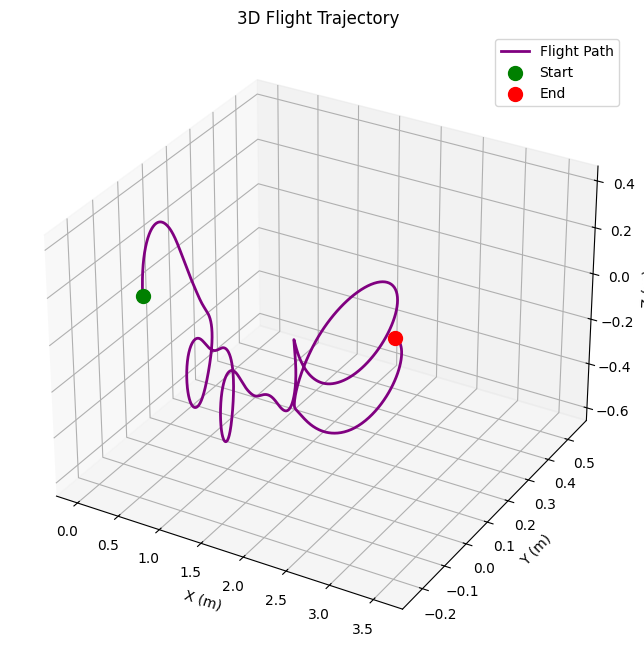

In [31]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(df['pos_x'], df['pos_y'], df['pos_z'], label='Flight Path', linewidth=2, color='purple')
ax.scatter(df['pos_x'].iloc[0], df['pos_y'].iloc[0], df['pos_z'].iloc[0], color='green', s=100, label='Start')
ax.scatter(df['pos_x'].iloc[-1], df['pos_y'].iloc[-1], df['pos_z'].iloc[-1], color='red', s=100, label='End')

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('3D Flight Trajectory')
ax.legend()
plt.savefig('../plot/3d_trajectory.png')
plt.show()

### 3. Velocity Over Time

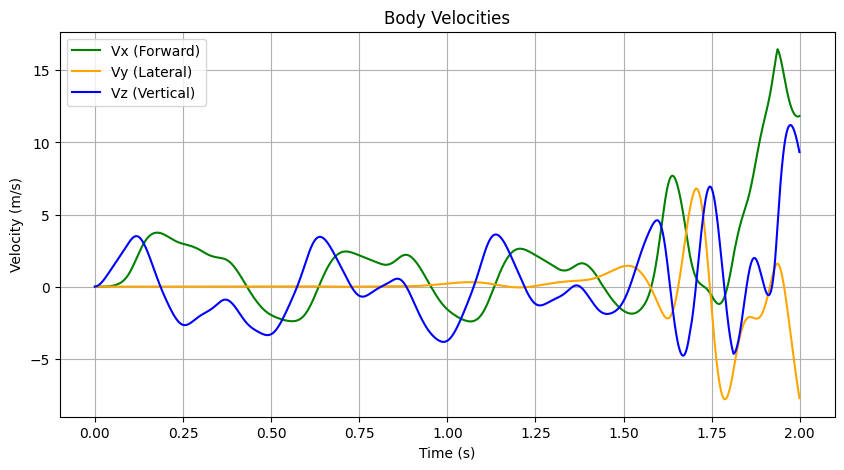

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(df['time'], df['vel_x'], label='Vx (Forward)', color='green')
plt.plot(df['time'], df['vel_y'], label='Vy (Lateral)', color='orange')
plt.plot(df['time'], df['vel_z'], label='Vz (Vertical)', color='blue')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Body Velocities')
plt.legend()
plt.grid()
plt.savefig('../plot/body_velocities.png')
plt.show()